# Dia 3 · Módulo 8 — Incerteza: intervalo de confiança e p-valor
### Estatística Básica Aplicada · Python

O Módulo 7 ensinou a desconfiar da **origem** dos dados. Falta desconfiar do **tamanho** da
diferença — porque duas médias nunca saem exatamente iguais, nem quando não existe diferença
nenhuma entre os grupos.

> ## O Pelotão A foi melhor que o B. Isso é um fato ou é o acaso do dia?
> ## E o que "estatisticamente significativo" realmente garante?

Este é o módulo com maior densidade de **conceitos mal usados** de todo o curso. Praticamente
tudo o que se lê sobre p-valor em relatórios está errado — inclusive em artigos publicados.

**O que a turma vai levar deste módulo:**
1. Toda estimativa tem uma **distribuição amostral** — e o `√n` do Módulo 2 governa a largura dela.
2. O **intervalo de confiança** diz o que os dados aguentam sustentar; e o que ele **não** diz.
3. O **p-valor** responde a uma pergunta muito mais estreita do que as pessoas imaginam.
4. **Significativo ≠ importante.** Com `n` grande, qualquer bobagem vira significativa.
5. Testar muitas coisas **garante** achar algo — e isso tem nome: p-hacking.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | Dois pelotões idênticos | diferença aparece mesmo sem existir |
| ① | Distribuição amostral | a estimativa também tem uma distribuição |
| ② | Intervalo de confiança | o que ele diz e o que não diz |
| ③ | p-valor | a pergunta estreita que ele responde |
| ④ | Significativo × importante | o `n` decide o primeiro, não o segundo |
| 💡 | *Bônus:* a régua Δ | **opcional** — quando o efeito é real e pequeno demais |
| ⑤ | Comparações múltiplas | procure bastante e você acha |
| ⑥ | Decisão: reportar incerteza | |

As seções ③, ④ e ⑤ formam um bloco só. Se o tempo apertar, reduza a ①, nunca esse bloco.
O **Bônus** da §④ é o primeiro a cair: é o trecho mais abstrato do módulo e nada depende dele.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

COR = {
    "media":    "#2a78d6",   # azul
    "dados":    "#9ec5f4",   # azul claro
    "verdade":  "#1baf7a",   # verde    — o valor real
    "alerta":   "#e34948",   # vermelho — o erro / o que não cobre
    "amostra":  "#4a3aa7",   # violeta  — a estimativa
    "neutro":   "#898781",
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ Dois pelotões rigorosamente idênticos

Vamos criar dois pelotões sorteados **da mesma população**. Por construção, não existe nenhuma
diferença real entre eles: mesma média verdadeira, mesmo desvio, mesmo tudo.

**Antes de rodar:** as médias dos dois vão sair iguais?

In [2]:
# --- Dois pelotões da MESMA população (nenhuma diferença real existe) ---
rng = np.random.default_rng(8)
MEDIA_REAL, SIGMA_REAL = 13.5, 1.8

pel_A = rng.normal(MEDIA_REAL, SIGMA_REAL, 12)
pel_B = rng.normal(MEDIA_REAL, SIGMA_REAL, 12)

print(f"média verdadeira dos DOIS pelotões: {MEDIA_REAL:.2f} min\n")
print(f"Pelotão A (12 militares): média = {pel_A.mean():.2f} min")
print(f"Pelotão B (12 militares): média = {pel_B.mean():.2f} min")
print(f"diferença observada     : {pel_A.mean() - pel_B.mean():+.2f} min")

print("\nUm relatório apressado escreveria: 'o Pelotão A tem desempenho superior ao B'.")
print("E estaria errado: nós MESMOS construímos os dois iguais.")

# quantas vezes uma diferença desse tamanho aparece só por acaso?
difs = np.array([rng.normal(MEDIA_REAL, SIGMA_REAL, 12).mean()
                 - rng.normal(MEDIA_REAL, SIGMA_REAL, 12).mean() for _ in range(10_000)])
obs = abs(pel_A.mean() - pel_B.mean())
print(f"\nRepetindo o sorteio 10.000 vezes (sempre SEM diferença real):")
print(f"  diferença típica só por acaso: {np.abs(difs).mean():.2f} min")
print(f"  diferença máxima só por acaso: {np.abs(difs).max():.2f} min")
print(f"  em {np.mean(np.abs(difs) >= obs):.0%} das vezes o acaso produz diferença >= {obs:.2f} min")

média verdadeira dos DOIS pelotões: 13.50 min

Pelotão A (12 militares): média = 12.86 min
Pelotão B (12 militares): média = 13.79 min
diferença observada     : -0.93 min

Um relatório apressado escreveria: 'o Pelotão A tem desempenho superior ao B'.
E estaria errado: nós MESMOS construímos os dois iguais.

Repetindo o sorteio 10.000 vezes (sempre SEM diferença real):
  diferença típica só por acaso: 0.60 min
  diferença máxima só por acaso: 2.89 min
  em 22% das vezes o acaso produz diferença >= 0.93 min


> ### 🔑 A ideia central do módulo
> **Diferença observada não é diferença real.** Todo número que você calcula a partir de uma
> amostra carrega um "balanço" que vem do simples fato de a amostra ser uma amostra.
>
> A pergunta correta nunca é *"os grupos deram diferente?"* (a resposta é sempre sim). É:
> **"essa diferença é maior do que o balanço que o acaso produziria sozinho?"**

Todo este módulo é o ferramental para responder a essa pergunta — e para não exagerar no que a
resposta significa.

---
# ① A distribuição amostral

Aqui está a ideia que sustenta tudo o que vem depois, e ela é mais simples do que o nome sugere.

Sua média amostral é **um** valor. Mas se você tivesse sorteado outros militares, teria obtido
outro valor. Se repetisse muitas vezes, esses valores formariam uma distribuição — a
**distribuição amostral da média**.

Você nunca a observa na prática (só tem uma amostra). Mas a estatística sabe descrevê-la:

- ela é **centrada** na média verdadeira da população (se a coleta for honesta — Módulo 7!);
- a largura dela é o **erro padrão**, `σ/√n` — o velho conhecido do Módulo 2, §⑤.

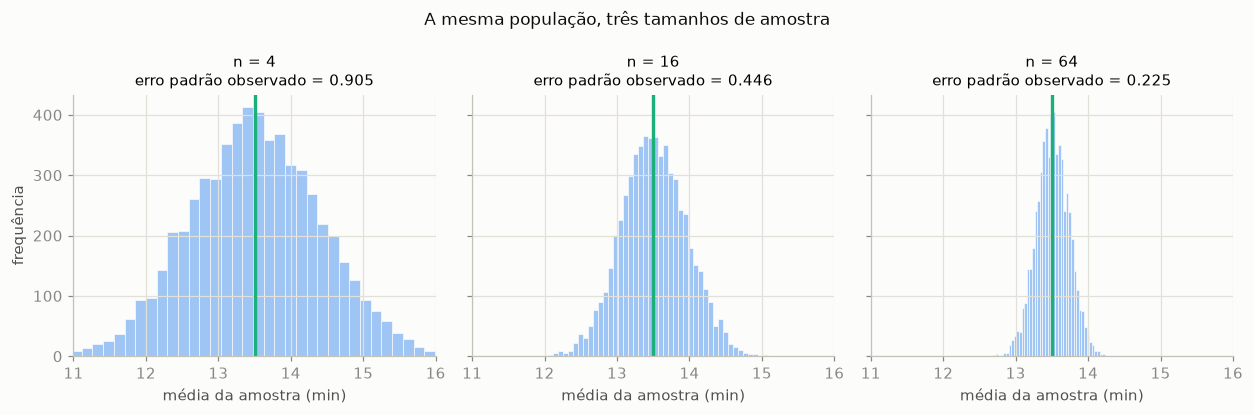

    n |  erro padrão observado |   σ/√n (previsto)
--------------------------------------------------
    4 |                  0.895 |             0.900
   16 |                  0.450 |             0.450
   64 |                  0.225 |             0.225
  256 |                  0.111 |             0.113

A fórmula acerta. E repare: para METADE do erro, é preciso QUADRUPLICAR o efetivo.
Esse é o preço do √n — o mesmo do Módulo 2, agora cobrando na direção contrária.


In [3]:
# --- Vendo a distribuição amostral (que na vida real fica invisível) ---
rng1 = np.random.default_rng(15)
POP_MEDIA, POP_SIGMA = 13.5, 1.8

fig, eixos = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
for eixo, n in zip(eixos, [4, 16, 64]):
    medias = np.array([rng1.normal(POP_MEDIA, POP_SIGMA, n).mean() for _ in range(6000)])
    eixo.hist(medias, bins=45, color=COR["dados"], edgecolor="white", linewidth=0.4)
    eixo.axvline(POP_MEDIA, color=COR["verdade"], linewidth=2.2)
    eixo.set_title(f"n = {n}\nerro padrão observado = {medias.std(ddof=1):.3f}", fontsize=10)
    eixo.set_xlim(11, 16)
    eixo.set_xlabel("média da amostra (min)")
eixos[0].set_ylabel("frequência")
fig.suptitle("A mesma população, três tamanhos de amostra", fontsize=11, color="#0b0b0b")
plt.tight_layout()
plt.show()

print(f"{'n':>5} | {'erro padrão observado':>22} | {'σ/√n (previsto)':>17}")
print("-" * 50)
for n in [4, 16, 64, 256]:
    medias = np.array([rng1.normal(POP_MEDIA, POP_SIGMA, n).mean() for _ in range(6000)])
    print(f"{n:>5} | {medias.std(ddof=1):>22.3f} | {POP_SIGMA / np.sqrt(n):>17.3f}")

print("\nA fórmula acerta. E repare: para METADE do erro, é preciso QUADRUPLICAR o efetivo.")
print("Esse é o preço do √n — o mesmo do Módulo 2, agora cobrando na direção contrária.")

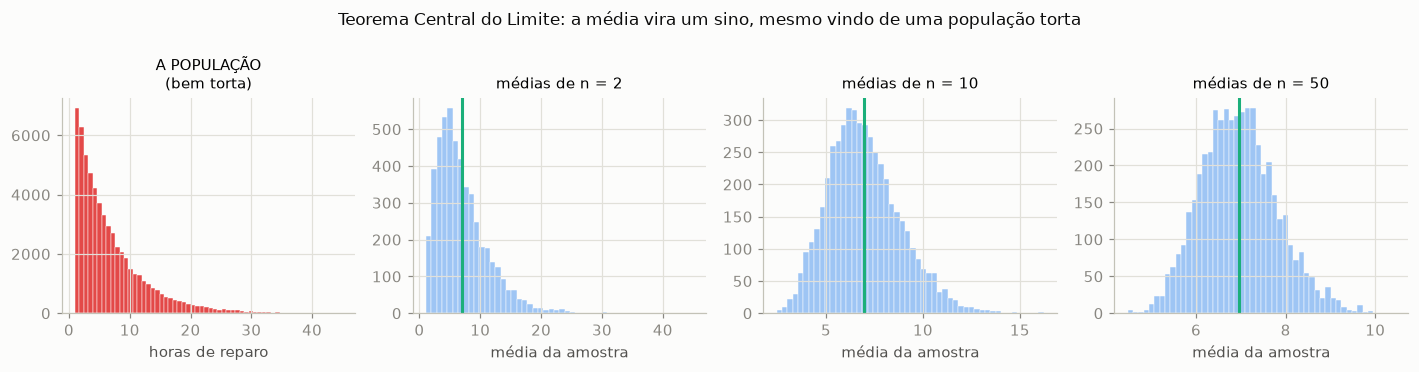

A população é assimétrica e feia. As MÉDIAS dela, não: já com n = 50 viram um sino.

É por isso que as fórmulas do curso funcionam mesmo quando os dados não são normais —
elas se aplicam à distribuição da MÉDIA, não à dos militares.

⚠️ MAS: quanto mais torta a população, MAIOR o n necessário. E o TCL não faz nada
   por caudas pesadíssimas (Módulo 1, §4.3) nem conserta viés de coleta (Módulo 7).


In [4]:
# --- O Teorema Central do Limite: a forma da população quase não importa ---
rng2 = np.random.default_rng(22)

# uma população TORTA: tempos de reparo (Módulo 3 — assimétrica, cauda longa)
pop_torta = rng2.exponential(6.0, 60_000) + 1.0

fig, eixos = plt.subplots(1, 4, figsize=(13, 3.4))
eixos[0].hist(pop_torta[pop_torta < 45], bins=60, color=COR["alerta"], edgecolor="white",
              linewidth=0.3)
eixos[0].set_title("A POPULAÇÃO\n(bem torta)", fontsize=10)
eixos[0].set_xlabel("horas de reparo")

for eixo, n in zip(eixos[1:], [2, 10, 50]):
    medias = np.array([rng2.choice(pop_torta, n).mean() for _ in range(5000)])
    eixo.hist(medias, bins=50, color=COR["dados"], edgecolor="white", linewidth=0.3)
    eixo.axvline(pop_torta.mean(), color=COR["verdade"], linewidth=2)
    eixo.set_title(f"médias de n = {n}", fontsize=10)
    eixo.set_xlabel("média da amostra")

fig.suptitle("Teorema Central do Limite: a média vira um sino, mesmo vindo de uma população torta",
             fontsize=11, color="#0b0b0b")
plt.tight_layout()
plt.show()

print("A população é assimétrica e feia. As MÉDIAS dela, não: já com n = 50 viram um sino.")
print("\nÉ por isso que as fórmulas do curso funcionam mesmo quando os dados não são normais —")
print("elas se aplicam à distribuição da MÉDIA, não à dos militares.")
print("\n⚠️ MAS: quanto mais torta a população, MAIOR o n necessário. E o TCL não faz nada")
print("   por caudas pesadíssimas (Módulo 1, §4.3) nem conserta viés de coleta (Módulo 7).")

---
# ② Intervalo de confiança

Em vez de reportar um número seco ("13,5 min"), reporta-se uma **faixa** que reflete o quanto a
estimativa poderia ter saído diferente por acaso.

A construção é direta: `média ± (fator) × erro padrão`. Para 95% de confiança, o fator ronda 2
(exatamente 1,96 para amostras grandes; um pouco mais para amostras pequenas — é o que a
distribuição *t* corrige).

**Antes de rodar:** se eu construir 100 intervalos de 95% a partir de 100 amostras diferentes,
quantos deles vão conter a média verdadeira?

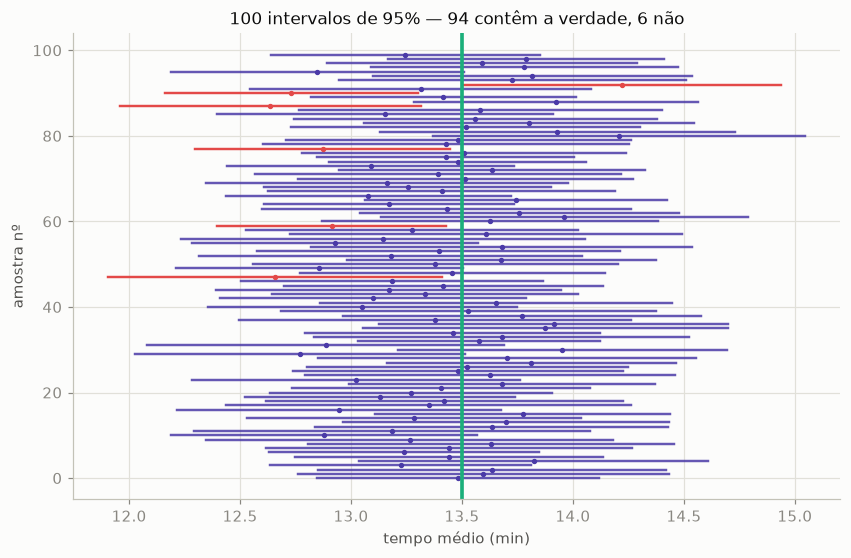

Intervalos que contêm a média verdadeira: 94 de 100

A VERDADE (linha verde) nunca se moveu. Quem se move é o INTERVALO,
porque ele é calculado a partir de uma amostra diferente a cada vez.


In [5]:
# --- 100 intervalos de confiança, e a verdade que conhecemos ---
rng3 = np.random.default_rng(2)
N_AM, N_MIL = 100, 25

plt.figure(figsize=(9, 5.5))
acertos = 0
for k in range(N_AM):
    am = rng3.normal(POP_MEDIA, POP_SIGMA, N_MIL)
    ep = am.std(ddof=1) / np.sqrt(N_MIL)                       # erro padrão
    fator = stats.t.ppf(0.975, df=N_MIL - 1)                   # ~2,06 para n = 25
    lo, hi = am.mean() - fator * ep, am.mean() + fator * ep
    pegou = lo <= POP_MEDIA <= hi
    acertos += pegou
    plt.plot([lo, hi], [k, k], color=COR["amostra"] if pegou else COR["alerta"],
             linewidth=1.6, alpha=0.85 if pegou else 1)
    plt.plot(am.mean(), k, "o", color=COR["amostra"] if pegou else COR["alerta"], markersize=2.5)

plt.axvline(POP_MEDIA, color=COR["verdade"], linewidth=2.4)
plt.title(f"100 intervalos de 95% — {acertos} contêm a verdade, {N_AM - acertos} não",
          color="#0b0b0b", fontsize=11)
plt.xlabel("tempo médio (min)"); plt.ylabel("amostra nº")
plt.show()

print(f"Intervalos que contêm a média verdadeira: {acertos} de {N_AM}")
print("\nA VERDADE (linha verde) nunca se moveu. Quem se move é o INTERVALO,")
print("porque ele é calculado a partir de uma amostra diferente a cada vez.")

### O que o IC diz — e o que ele não diz

> **"95% de confiança" é uma propriedade do MÉTODO, não daquele intervalo específico.**
>
> Significa: *se eu repetisse todo o procedimento muitas vezes, 95% dos intervalos que eu
> produzisse conteriam o valor verdadeiro.* Foi exatamente o que o gráfico acima mostrou.

| ❌ Interpretação errada | ✅ O que é correto dizer |
|---|---|
| "há 95% de chance de a média real estar neste intervalo" | "o método acerta em 95% das vezes" |
| "95% dos militares estão nesta faixa" | isso é **desvio padrão**, não erro padrão (Módulo 2, §⑤) |
| "o IC não pegou o valor, logo houve erro de cálculo" | 5% das vezes ele **erra**, por construção |
| "IC estreito = resultado confiável" | estreito só significa `n` grande — **viés não entra no IC** |

A última linha é a mais importante para o Dia 3: o intervalo de confiança mede **apenas** a
variância amostral. Ele não sabe nada sobre viés de coleta, não sabe que os aviões abatidos não
foram contados, não sabe que só os insatisfeitos responderam. **Um IC estreitíssimo em torno de
um número errado é o produto típico de uma base grande e torta** (Módulo 7, §③).

---
# ③ p-valor

O p-valor responde a **uma pergunta específica e bastante estreita**:

> Supondo que **não exista diferença nenhuma** entre os grupos, qual a probabilidade de eu
> observar uma diferença **pelo menos tão grande** quanto a que observei, só por acaso?

Se essa probabilidade for muito pequena, a explicação "foi só acaso" fica desconfortável.

Repare no que está embutido: o p-valor é calculado **assumindo que a hipótese nula é verdadeira**.
Ele não pode, portanto, dizer qual a probabilidade de ela ser verdadeira — seria circular.

In [6]:
# --- O p-valor em dois mundos: sem efeito e com efeito ---
rng4 = np.random.default_rng(50)

print("MUNDO 1 — os dois pelotões são IDÊNTICOS (nenhum efeito real)")
for k in range(5):
    a = rng4.normal(13.5, 1.8, 20)
    b = rng4.normal(13.5, 1.8, 20)
    p = stats.ttest_ind(a, b).pvalue
    marca = "  <-- 'significativo'!" if p < 0.05 else ""
    print(f"  estudo {k+1}: dif = {a.mean()-b.mean():+.2f} min | p = {p:.3f}{marca}")

print("\nMUNDO 2 — existe efeito real de 1,5 min")
for k in range(5):
    a = rng4.normal(13.5, 1.8, 20)
    b = rng4.normal(12.0, 1.8, 20)
    p = stats.ttest_ind(a, b).pvalue
    marca = "  <-- 'significativo'!" if p < 0.05 else "  <-- NÃO detectou!"
    print(f"  estudo {k+1}: dif = {a.mean()-b.mean():+.2f} min | p = {p:.4f}{marca}")

print("\nNo mundo SEM efeito, o p às vezes desce abaixo de 0,05 (falso positivo).")
print("No mundo COM efeito, o p às vezes fica acima de 0,05 (falso negativo).")
print("\nO p-valor é uma evidência, não um veredito. E ele varia MUITO de estudo para estudo.")

MUNDO 1 — os dois pelotões são IDÊNTICOS (nenhum efeito real)
  estudo 1: dif = -0.34 min | p = 0.575
  estudo 2: dif = -0.67 min | p = 0.250
  estudo 3: dif = -0.10 min | p = 0.865
  estudo 4: dif = -0.86 min | p = 0.141
  estudo 5: dif = -0.76 min | p = 0.190

MUNDO 2 — existe efeito real de 1,5 min
  estudo 1: dif = +1.14 min | p = 0.0518  <-- NÃO detectou!
  estudo 2: dif = +2.14 min | p = 0.0001  <-- 'significativo'!
  estudo 3: dif = +1.85 min | p = 0.0004  <-- 'significativo'!
  estudo 4: dif = +1.94 min | p = 0.0006  <-- 'significativo'!
  estudo 5: dif = +0.87 min | p = 0.0765  <-- NÃO detectou!

No mundo SEM efeito, o p às vezes desce abaixo de 0,05 (falso positivo).
No mundo COM efeito, o p às vezes fica acima de 0,05 (falso negativo).

O p-valor é uma evidência, não um veredito. E ele varia MUITO de estudo para estudo.


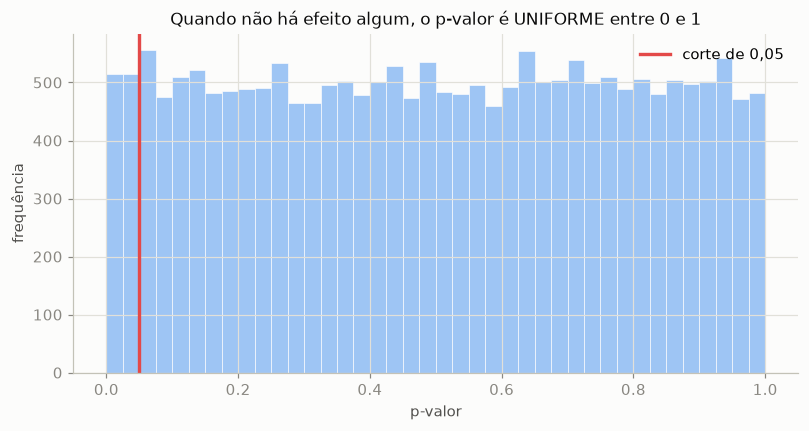

fração de estudos com p < 0,05, SEM nenhum efeito real: 5.1%

Esse 5% NÃO é um defeito: é a DEFINIÇÃO do corte. Ao adotar 0,05, você aceita
errar 1 vez em 20 quando não há efeito nenhum.

E é justamente essa taxa que a seção ⑤ vai explorar — para o mal.


In [7]:
# --- A distribuição do p quando NÃO há efeito nenhum ---
rng5 = np.random.default_rng(60)
ps_nulo = np.array([stats.ttest_ind(rng5.normal(13.5, 1.8, 20),
                                    rng5.normal(13.5, 1.8, 20)).pvalue for _ in range(20_000)])

plt.figure(figsize=(8.5, 4))
plt.hist(ps_nulo, bins=40, color=COR["dados"], edgecolor="white", linewidth=0.4)
plt.axvline(0.05, color=COR["alerta"], linewidth=2.2, label="corte de 0,05")
plt.title("Quando não há efeito algum, o p-valor é UNIFORME entre 0 e 1",
          color="#0b0b0b", fontsize=11)
plt.xlabel("p-valor"); plt.ylabel("frequência")
plt.legend(frameon=False)
plt.show()

print(f"fração de estudos com p < 0,05, SEM nenhum efeito real: {np.mean(ps_nulo < 0.05):.1%}")
print("\nEsse 5% NÃO é um defeito: é a DEFINIÇÃO do corte. Ao adotar 0,05, você aceita")
print("errar 1 vez em 20 quando não há efeito nenhum.")
print("\nE é justamente essa taxa que a seção ⑤ vai explorar — para o mal.")

### O que o p-valor NÃO é

| ❌ Frase que você vai ler por aí | ✅ Por que está errada |
|---|---|
| "p = 0,03 → 3% de chance de a hipótese nula ser verdadeira" | ele **assume** a nula verdadeira para se calcular |
| "p = 0,03 → 97% de chance de o efeito ser real" | mesma inversão, com outra roupa |
| "p > 0,05 → provamos que não há diferença" | **ausência de evidência ≠ evidência de ausência** |
| "p = 0,001 → o efeito é enorme" | p mede **evidência**, não **tamanho** (§④) |
| "p < 0,05 → o resultado se repetirá" | o p varia muito entre repetições (§③) |

> A confusão mais frequente é a primeira: **inverter a condicional**. O p-valor é a probabilidade
> *dos dados, supondo a nula*. Não é a probabilidade *da nula, dados os dados*.
>
> Analogia: a probabilidade de alguém ser militar **dado que** está fardado é altíssima. A
> probabilidade de alguém estar fardado **dado que** é militar é bem menor (folga, férias, à
> paisana). São duas perguntas diferentes, e trocá-las muda tudo.

---
# ④ Significativo × importante

Esta seção é a que mais protege você ao ler artigos — especialmente artigos de IA, onde as
amostras são gigantescas.

Comece por um fato incômodo: **o mundo é imperfeito e nós somos imperfeitos.** Essa imperfeição
entra no experimento e nunca será totalmente isolada — sempre sobra alguma diferença real, em
alguma casa decimal. Duas formulações de repelente nunca protegem por *exatamente* o mesmo
tempo. Dois pelotões nunca correm em *exatamente* a mesma média. Até o paquímetro muda de
comportamento quando quem mede se cansa.

Ou seja: a hipótese nula, que afirma **igualdade exata**, quase nunca é verdadeira — e isso
antes de você coletar o primeiro dado.

O p-valor depende de **três** coisas: o tamanho do efeito, a variabilidade e o **`n`**. Como o
`n` entra na conta, e como sempre sobra *algum* efeito, qualquer diferença — por mais
irrelevante que seja — pode ser empurrada para baixo de 0,05, bastando medir gente suficiente.

E repare no que isso significa: quando o teste rejeita, **ele não está errando**. A diferença
existe mesmo. Ele apenas não sabe dizer se ela **importa** — e essa segunda pergunta não é
estatística, é operacional.

**Antes de rodar:** existe uma diferença **real** de 3 segundos (0,05 min) entre dois pelotões.
Isso não muda absolutamente nada na operação. A partir de que `n` ela vira "significativa"?

In [8]:
# --- Uma diferença irrelevante de 3 segundos, medida com n crescente ---
rng6 = np.random.default_rng(77)
DIFERENCA_REAL = 0.05          # minutos = 3 segundos. Operacionalmente: nada.

# para cada n, repetimos o estudo 200 vezes e olhamos o p TÍPICO (mediano).
# (um único estudo balança muito — como a §③ mostrou.)
print(f"diferença real entre os grupos: {DIFERENCA_REAL:.2f} min (3 segundos)\n")
print(f"{'n por grupo':>12} | {'p típico':>10} | {'% dos estudos com p<0,05':>25} | {'importa?':>9}")
print("-" * 68)
for n in [20, 100, 500, 2_000, 10_000, 50_000]:
    ps = np.array([stats.ttest_ind(rng6.normal(13.50, 1.8, n),
                                   rng6.normal(13.50 - DIFERENCA_REAL, 1.8, n)).pvalue
                   for _ in range(200)])
    print(f"{n:>12} | {np.median(ps):>10.4f} | {np.mean(ps < 0.05):>24.0%} | {'não':>9}")

print("\nA coluna 'importa?' nunca muda: 3 segundos continuam sendo 3 segundos.")
print("A coluna da direita vai de 4% para 98% só porque medimos mais gente.")
print("\n'Estatisticamente significativo' responde: 'dá para descartar o acaso?'")
print("NÃO responde: 'isso muda alguma decisão?'. Essa segunda pergunta é sua, não da fórmula.")

diferença real entre os grupos: 0.05 min (3 segundos)

 n por grupo |   p típico |  % dos estudos com p<0,05 |  importa?
--------------------------------------------------------------------
          20 |     0.4788 |                       4% |       não
         100 |     0.4695 |                       8% |       não


         500 |     0.4403 |                       8% |       não
        2000 |     0.3472 |                      16% |       não


       10000 |     0.0565 |                      48% |       não


       50000 |     0.0000 |                      98% |       não

A coluna 'importa?' nunca muda: 3 segundos continuam sendo 3 segundos.
A coluna da direita vai de 4% para 98% só porque medimos mais gente.

'Estatisticamente significativo' responde: 'dá para descartar o acaso?'
NÃO responde: 'isso muda alguma decisão?'. Essa segunda pergunta é sua, não da fórmula.


> ### 🔑 Por isso reporte o TAMANHO DO EFEITO, com unidade
>
> "A diferença foi de **0,05 min (IC 95%: 0,02 a 0,08)**" informa muito mais que "a diferença foi
> significativa (p < 0,001)". A primeira frase permite ao comando julgar se vale a pena agir; a
> segunda não permite nada.
>
> **Sempre que um resultado for apresentado apenas com p-valor, peça o tamanho do efeito.** É a
> pergunta mais útil deste curso inteiro, e serve para qualquer artigo.

E o inverso também acontece: um efeito **grande e importante** pode dar `p > 0,05` só porque a
amostra era pequena. Nesse caso o certo é dizer *"não conseguimos detectar"* — nunca
*"provamos que não existe"*.

> 💡 **Se sobrar tempo:** o Bônus logo abaixo mostra como transformar *"qual é o tamanho
> do efeito?"* numa decisão de sim-ou-não — com uma régua declarada **antes** da coleta.

---
## 💡 Bônus — a régua Δ: e se a diferença for real, mas pequena demais?

*(Opcional, e é o trecho mais abstrato do módulo. Nada do que vem depois depende dele — mas
é ele que transforma a §④ de advertência em decisão.)*

A §④ deixou uma pergunta em aberto. Se toda diferença é real em alguma casa decimal, e se `n`
suficiente sempre acaba acusando significância, como é que alguém decide alguma coisa?

Mudando a forma da pergunta:

> ❌ *"existe diferença?"* — a resposta já era **sim** antes da coleta começar
> ✅ **"a diferença é maior do que a menor diferença que mudaria a minha conduta?"**

Chame essa menor diferença de **Δ**. Três exigências:

1. **Δ vem da operação, nunca da estatística.** Quem fixa é quem decide — o comando, o médico,
   o engenheiro. O estatístico só pergunta e anota.
2. **Δ é declarado ANTES da coleta.** Se você olha o resultado e só então decide o que seria
   relevante, a régua vira negociável — e isso é um primo próximo do p-hacking da §⑤.
3. **Δ tem unidade.** Horas de proteção, minutos de corrida, pontos numa escala. "5%" quase
   nunca é uma régua honesta.

A experiência do pesquisador não se gasta julgando o resultado depois de vê-lo. Gasta-se
**escolhendo Δ antes** — e depois obedecendo.

---

**O caso.** O **LQFEx** (Laboratório Químico Farmacêutico do Exército) desenvolveu uma nova
formulação (v2) do repelente operacional e precisa saber se ela substitui a atual na linha de
produção. O desfecho é o padrão da área: **tempo de proteção completa** — horas até a primeira
picada confirmada.

O Δ foi fixado pelo comando, antes do ensaio, em **1 hora**. O raciocínio não é estatístico:
menos que isso não elimina nenhuma reaplicação no ciclo de uma patrulha, e portanto não muda
nada na mochila nem na logística de ninguém.

**Antes de rodar:** o ensaio vai medir 1.200 militares por grupo. Se a v2 for cerca de 10
minutos melhor que a v1, o teste vai acusar significância?

In [ ]:
# --- Ensaio do repelente LQFEx: v2 contra a formulação atual ---
rng6b = np.random.default_rng(88)

DELTA = 1.0            # h — a régua, DECLARADA ANTES pelo comando
N     = 1200           # militares por grupo
efeito_real = 0.15     # h = 9 min — existe, mas é miúdo

v1 = rng6b.normal(5.80, 1.20, N)                  # formulação atual
v2 = rng6b.normal(5.80 + efeito_real, 1.20, N)    # nova formulação

dif  = v2.mean() - v1.mean()
ep   = np.sqrt(v1.var(ddof=1)/N + v2.var(ddof=1)/N)
p    = stats.ttest_ind(v2, v1).pvalue
ic95 = (dif - 1.96*ep,  dif + 1.96*ep)
ic90 = (dif - 1.645*ep, dif + 1.645*ep)           # o TOST usa o de 90%

print(f"Régua declarada ANTES do ensaio: Δ = {DELTA:.1f} h\n")
print(f"{'formulação atual (v1)':<24} | proteção média = {v1.mean():.2f} h")
print(f"{'nova formulação (v2)':<24} | proteção média = {v2.mean():.2f} h")
print(f"\ndiferença observada : {dif:+.3f} h  ({dif*60:+.0f} min)")
print(f"IC 95%              : [{ic95[0]:+.3f}, {ic95[1]:+.3f}] h")
print(f"p-valor             : {p:.2e}")

print(f"\n{'PERGUNTA':<46} | {'RESPOSTA':>8}")
print("-" * 58)
print(f"{'O efeito existe?  (o IC 95% exclui o zero?)':<46} | "
      f"{'SIM' if not (ic95[0] <= 0 <= ic95[1]) else 'não':>8}")
print(f"{'O efeito importa? (o IC 95% ultrapassa Δ?)':<46} | "
      f"{'SIM' if (ic95[0] < -DELTA or ic95[1] > DELTA) else 'NÃO':>8}")

# teste de equivalência (TOST): H0 é "a diferença IMPORTA", |δ| >= Δ
p_tost = max(stats.t.sf((dif + DELTA)/ep, 2*N - 2),
             stats.t.cdf((dif - DELTA)/ep, 2*N - 2))
print(f"\nTeste de equivalência (TOST) — aqui a nula é 'a diferença importa', |δ| ≥ {DELTA:.1f} h")
print(f"  IC 90% : [{ic90[0]:+.3f}, {ic90[1]:+.3f}] h — cabe inteiro dentro da faixa? "
      f"{'sim' if -DELTA < ic90[0] and ic90[1] < DELTA else 'não'}")
print(f"  p(TOST): {p_tost:.1e} — equivalência operacional DEMONSTRADA")

print(f"\nLaudo ao comando: a v2 protege {dif*60:.0f} minutos a mais. O efeito é real e está")
print("medido com precisão — e não justifica trocar a linha de produção.")
print("\nRepare na inversão: foi o n GRANDE que permitiu CRAVAR a irrelevância. Com n")
print("pequeno o IC seria largo demais e o laudo teria de ser 'não sabemos'.")

In [ ]:
# --- Quatro ensaios, a mesma régua: o que cada um autoriza a dizer ---
ensaios = [
    ("A — nova base repelente",     "n = 900",   1.80,  1.20, 2.40),
    ("B — v2 da formulação atual",  "n = 1.200", 0.19,  0.10, 0.28),
    ("C — troca de solvente",       "n = 700",   0.10, -0.30, 0.50),
    ("D — piloto com 1 pelotão",    "n = 40",    0.60, -1.40, 2.60),
]

fig, eixo = plt.subplots(figsize=(9.5, 4.0))
eixo.axvspan(-DELTA, DELTA, color=COR["dados"], alpha=0.30, zorder=0)
eixo.axvline(0, color=COR["neutro"], linewidth=1.4, zorder=1)
for x in (-DELTA, DELTA):
    eixo.axvline(x, color=COR["media"], linewidth=1.6, linestyle="--", zorder=1)

for i, (rot, n, d, lo, hi) in enumerate(ensaios):
    y = len(ensaios) - 1 - i
    existe  = not (lo <= 0 <= hi)
    importa = (lo < -DELTA) or (hi > DELTA)
    veredicto = ("adote"              if existe and importa else
                 "real, não compensa" if existe             else
                 "inconclusivo"       if importa            else "equivalente")
    cor = (COR["verdade"] if veredicto == "adote" else
           COR["alerta"]  if veredicto == "inconclusivo" else COR["amostra"])
    eixo.plot([lo, hi], [y, y], color=cor, linewidth=3, solid_capstyle="round", zorder=3)
    eixo.plot([d], [y], "o", color=cor, markersize=8, zorder=4)
    eixo.annotate(veredicto, xy=(3.05, y), va="center", fontsize=9, color=cor, weight="bold")
    eixo.annotate(n, xy=(-2.85, y), va="center", fontsize=8, color=COR["neutro"])

eixo.set_yticks(range(len(ensaios)))
eixo.set_yticklabels([e[0] for e in ensaios][::-1], fontsize=9)
eixo.set_xlim(-3.0, 4.3); eixo.set_ylim(-0.7, len(ensaios) - 0.3)
eixo.set_xlabel("ganho de proteção sobre a formulação atual (horas)")
eixo.set_title("A régua Δ = 1 h decide; o zero sozinho não decide nada",
               color="#0b0b0b", fontsize=11)
eixo.annotate("faixa de irrelevância\noperacional", xy=(0, -0.55), ha="center",
              fontsize=8, color=COR["media"])
eixo.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("Os ensaios B e C dariam manchetes opostas se você só olhasse o p-valor —")
print("B é 'significativo', C não é. Contra a régua Δ, os dois dizem a MESMA coisa:")
print("pode seguir com a formulação atual.")
print("\nE o D, que tem a MAIOR diferença observada depois do A, não autoriza nada.")

> ### 🔑 Os quatro veredictos
>
> | O IC exclui o zero? | O IC ultrapassa Δ? | Veredicto | O que se diz ao comando |
> |---|---|---|---|
> | sim | sim | **adote** | "o ganho é real e relevante" |
> | sim | não | **real, não compensa** | "o ganho existe e é pequeno demais para pesar" |
> | não | não | **equivalente** | "se há diferença, ela não importa" |
> | não | sim | **inconclusivo** | "não sabemos — o ensaio foi pequeno demais" |
>
> As duas linhas do meio são as que o p-valor sozinho **não distingue**. E repare nas duas de
> baixo: ambas dão `p > 0,05`, e são conclusões **opostas** — uma é resposta, a outra é falta de
> dados. Só o Δ separa. É a diferença entre *"não detectamos"* e *"provamos que é igual"* da
> §⑥, agora com régua.

E é por isso que a pergunta certa quase nunca é a primeira que ocorre. Não é *"o repelente do
LQFEx funciona?"* — alguma coisa ele faz, e com `n` suficiente você prova que faz. A pergunta
que o comando precisa responder é outra:

> ## Compensa?

---
# ⑤ Comparações múltiplas: procure bastante e você acha

Você já viu na §③ que, sem efeito nenhum, 5% dos testes dão `p < 0,05`. Agora junte isso a uma
prática comuníssima: testar **muitas** hipóteses e reportar as que deram certo.

In [9]:
# --- O S3 cruza 20 variáveis contra o desempenho. Nenhuma tem relação real. ---
rng7 = np.random.default_rng(99)

variaveis = ["idade", "altura", "peso", "nº de irmãos", "tempo de serviço", "escolaridade",
             "distância de casa", "horas de sono", "consumo de café", "tipo sanguíneo",
             "mês de nascimento", "nº do calçado", "tempo de banho", "marca do tênis",
             "posição na fila", "cor dos olhos", "nº de tatuagens", "time do coração",
             "letra do sobrenome", "hora de acordar"]

desempenho = rng7.normal(13.5, 1.8, 60)
achados = []
for v in variaveis:
    x = rng7.normal(0, 1, 60)                       # SEM nenhuma relação com o desempenho
    r, p = stats.pearsonr(x, desempenho)
    achados.append((v, r, p))
    if p < 0.05:
        print(f"  ✓ ACHADO: '{v}' correlaciona com desempenho (r = {r:+.2f}, p = {p:.3f})")

n_sig = sum(1 for _, _, p in achados if p < 0.05)
print(f"\nTestamos {len(variaveis)} variáveis. Nenhuma tem relação real com o desempenho.")
print(f"Encontramos {n_sig} resultado(s) 'significativo(s)'.")

# a probabilidade de achar PELO MENOS um, quando nada é real
prob = 1 - 0.95 ** len(variaveis)
print(f"\nProbabilidade de achar pelo menos 1 falso positivo em 20 testes: {prob:.0%}")
print("\nO relatório vai destacar o achado e esquecer os 19 testes que não deram nada.")
print("O leitor do relatório nunca fica sabendo que houve 20 tentativas.")

  ✓ ACHADO: 'nº de tatuagens' correlaciona com desempenho (r = +0.26, p = 0.044)

Testamos 20 variáveis. Nenhuma tem relação real com o desempenho.
Encontramos 1 resultado(s) 'significativo(s)'.

Probabilidade de achar pelo menos 1 falso positivo em 20 testes: 64%

O relatório vai destacar o achado e esquecer os 19 testes que não deram nada.
O leitor do relatório nunca fica sabendo que houve 20 tentativas.


### Como isso acontece sem ninguém ser desonesto

Quase nunca é fraude. É o caminho natural de quem analisa dados com boa-fé:

- testar vários **subgrupos** ("e só entre os sargentos?", "e só na 2ª companhia?");
- experimentar várias **definições** da variável ("tempo bruto? tempo ajustado? posição?");
- decidir **depois de ver os dados** quais comparações reportar;
- parar de coletar **assim que** o resultado ficou significativo.

Cada uma dessas decisões multiplica as chances de encontrar um falso positivo. O conjunto tem
nome: **p-hacking**.

| Defesa | Como funciona |
|---|---|
| **Declarar as hipóteses antes** de olhar os dados | separa confirmação de exploração |
| **Corrigir para múltiplos testes** (ex.: Bonferroni) | exige p menor quando há muitos testes |
| **Reportar TODOS os testes feitos** | dá ao leitor o denominador |
| **Replicar** em dados novos | o falso positivo não se repete |

> **Ao ler um artigo, a pergunta é:** *quantas comparações foram feitas antes de chegar a esta?*
> Se o texto não permite saber, o p-valor apresentado não é interpretável.
>
> Correção de Bonferroni, na prática: com 20 testes, exija `p < 0,05/20 = 0,0025` para cada um.
> É conservadora, mas honesta.

---
# ⑥ Decisão: como reportar incerteza ao comando

| A pergunta real é... | Reporte | Nunca reporte sozinho |
|---|---|---|
| "qual é o valor?" | estimativa **+ IC** | o número seco |
| "a diferença é real?" | **tamanho do efeito + IC** | só o p-valor |
| "quanto isso muda a operação?" | o efeito **na unidade** do problema | "significativo" |
| "não deu diferença" | "**não detectamos**" + o IC | "provamos que é igual" |
| "achamos uma relação" | **quantos testes** foram feitos | só o que deu certo |
| "a base é enorme" | também a **origem** dela | IC estreito como prova de qualidade |

### Três frases para levar

1. **Diferença sempre aparece.** A pergunta é se ela é maior que o balanço do acaso.
2. **O p-valor responde uma pergunta estreita** — e não é "qual a chance de eu estar certo".
3. **Significativo ≠ importante.** Com `n` grande tudo fica significativo; só o **tamanho do
   efeito** diz se muda alguma coisa.

---
# ⑦ Exercícios

**Exercício 1 — Preveja antes de rodar.**

1. Na §②, se eu trocar a confiança de 95% para 99%, os intervalos ficam mais largos ou mais
   estreitos? E quantos dos 100 conteriam a verdade?
2. Na §④, o que acontece com a coluna do p-valor se a diferença real for **zero**?
3. Na §⑤, se o S3 testasse 100 variáveis em vez de 20, quantos "achados" você esperaria?

**Exercício 2 — Mude um parâmetro.**

Na célula da §③ (os dois mundos), mude o efeito real do Mundo 2 de `1,5` para `0,4` min, mantendo
n = 20. Rode várias vezes. Pergunta: com efeito pequeno e amostra pequena, com que frequência o
teste **deixa de detectar** um efeito que existe de verdade? Que nome tem esse erro?

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Um artigo conclui:

> "O novo protocolo de treinamento reduziu o tempo médio em 0,08 min (p = 0,004; n = 12.000).
> Como p < 0,01, há 99,6% de probabilidade de o protocolo ser eficaz. Recomendamos a adoção
> imediata em toda a Força. Não houve diferença entre homens e mulheres (p = 0,31), o que
> comprova que o protocolo funciona igualmente para ambos."

Há **quatro** erros conceituais. Encontre os quatro. *(Dicas: §③, §④ e a linha "não detectamos"
da §⑥.)*

**Exercício 4 — Interprete (discussão em grupo).**

Dois estudos sobre o mesmo simulador de tiro:

- **Estudo X:** n = 40. Melhora de **12 pontos**, IC 95% de −2 a +26, p = 0,09.
- **Estudo Y:** n = 9.000. Melhora de **0,4 ponto**, IC 95% de 0,1 a 0,7, p = 0,002.

1. Qual dos dois tem o resultado "estatisticamente significativo"?
2. Qual dos dois encontrou o efeito **operacionalmente relevante**?
3. O Estudo X "provou que o simulador não funciona"? O que exatamente ele mostrou?
4. Que estudo você recomendaria fazer em seguida, e com que `n` aproximado?

---
## Resumo do módulo

| Ferramenta | Responde | Cuidado |
|---|---|---|
| **Distribuição amostral** | como a estimativa balança | você nunca a observa; ela é deduzida |
| **Erro padrão** `σ/√n` | a largura desse balanço | ≠ desvio padrão (Módulo 2, §⑤) |
| **TCL** | por que a média vira sino | não conserta viés nem cauda pesadíssima |
| **Intervalo de confiança** | que valores os dados sustentam | mede **variância**, não viés |
| **p-valor** | "dá para descartar o acaso?" | não é a probabilidade da hipótese |
| **Tamanho do efeito** | "muda alguma coisa?" | é o que o comando precisa |
| **Correção múltipla** | protege de procurar demais | exige declarar quantos testes |

- **Diferença observada sempre existe**; o acaso produz diferença sozinho.
- **IC e p medem apenas o acaso amostral.** Contra viés (Módulo 7), eles são cegos.
- **`n` grande torna tudo significativo** — e nada disso torna nada importante.

➡️ **Próximo módulo:** o fechamento do curso. Você já tem tudo o que precisa para ler um
resultado de IA com olhos de estatístico: uma acurácia é uma **média** (Dia 1), um modelo é uma
máquina de **correlação** (Dia 2), o conjunto de treino é uma **amostra** (§⑦), e a diferença
entre dois modelos num benchmark é uma **diferença que pode ser acaso** (este módulo).